# Intelligent UPI Fraud Detection Using Predictive Analytics

## Project Objective

Develop a machine learning system to identify potentially fraudulent UPI transactions using transaction-level features and supervised learning techniques.

1. Import Libraries

In [4]:
# NumPy is used for numerical calculations and array operations
import numpy as np

# Pandas is used for loading, cleaning, and analyzing tabular data
import pandas as pd

# Matplotlib is used to create data visualizations
import matplotlib.pyplot as plt

# Seaborn provides easier and more informative statistical visualizations
import seaborn as sns

# Suppress warning messages so that notebook output remains clean
import warnings
warnings.filterwarnings("ignore")

2. Read the Dataset

In [5]:
# Read the generated UPI fraud dataset from the data folder
# df is a Pandas DataFrame that stores the complete dataset
df = pd.read_csv("../data/upi_fraud_data.csv")

# Display the first 5 rows to understand the structure of the data
df.head()

,transaction_id,timestamp,user_id,receiver_id,amount,transaction_type,location,device_type,is_rooted_device,network_type,time_of_day,is_fraud
0,100001,2025-01-01 00:00:00.000000,1103,5974,257.67,merchant_payment,Ahmedabad,mobile,0,4G,night,0
1,100002,2025-01-01 01:45:08.461492,1436,5632,216.09,merchant_payment,Delhi,mobile,0,WiFi,night,0
2,100003,2025-01-01 03:30:16.922984,1861,5894,190.54,send,Pune,mobile,0,5G,night,0
3,100004,2025-01-01 05:15:25.384476,1271,5567,403.96,receive,Bangalore,mobile,1,4G,night,1
4,100005,2025-01-01 07:00:33.845969,1107,5027,591.74,merchant_payment,Kolkata,mobile,0,WiFi,morning,1


In [6]:
# Display the last 5 rows of the dataset
# This helps verify that the dataset was loaded completely
df.tail()

,transaction_id,timestamp,user_id,receiver_id,amount,transaction_type,location,device_type,is_rooted_device,network_type,time_of_day,is_fraud
4995,104996,2025-12-31 16:59:25.154030,1290,5915,200.30,merchant_payment,Hyderabad,mobile,0,4G,afternoon,0
4996,104997,2025-12-31 18:44:33.615523,1295,5210,486.93,merchant_payment,Chennai,mobile,0,5G,evening,0
4997,104998,2025-12-31 20:29:42.077015,1451,5741,842.70,merchant_payment,Hyderabad,mobile,0,4G,evening,0
4998,104999,2025-12-31 22:14:50.538507,1904,5862,443.48,send,Ahmedabad,mobile,0,4G,evening,0
4999,105000,2025-12-31 23:59:59.000000,1215,5275,183.38,receive,Bangalore,mobile,1,WiFi,evening,0


3. Understand the Dataset

In [7]:
# Check the number of rows and columns in the dataset
# Rows represent individual UPI transactions
# Columns represent transaction features
df.shape

(5000, 12)

In [8]:
# Display all column names available in the dataset
# These columns will be used during data analysis and model development
df.columns

Index(['transaction_id', 'timestamp', 'user_id', 'receiver_id', 'amount',
       'transaction_type', 'location', 'device_type', 'is_rooted_device',
       'network_type', 'time_of_day', 'is_fraud'],
      dtype='str')

In [9]:
# Display column names, number of non-null values, and data types
# This helps identify numerical, categorical, and date/time columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    5000 non-null   int64  
 1   timestamp         5000 non-null   str    
 2   user_id           5000 non-null   int64  
 3   receiver_id       5000 non-null   int64  
 4   amount            5000 non-null   float64
 5   transaction_type  5000 non-null   str    
 6   location          5000 non-null   str    
 7   device_type       5000 non-null   str    
 8   is_rooted_device  5000 non-null   int64  
 9   network_type      5000 non-null   str    
 10  time_of_day       5000 non-null   str    
 11  is_fraud          5000 non-null   int64  
dtypes: float64(1), int64(5), str(6)
memory usage: 748.2 KB


In [10]:
# Generate statistical information for numerical columns
# Includes count, mean, standard deviation, minimum, maximum, and quartiles
df.describe()

,transaction_id,user_id,receiver_id,amount,is_rooted_device,is_fraud
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,102500.500000,1506.701200,5502.240000,803.362778,0.050200,0.092200
std,1443.520003,290.836902,288.619524,1030.797911,0.218379,0.289337
min,100001.000000,1001.000000,5001.000000,12.080000,0.000000,0.000000
25%,101250.750000,1254.000000,5248.000000,249.762500,0.000000,0.000000
50%,102500.500000,1511.000000,5503.000000,491.895000,0.000000,0.000000
75%,103750.250000,1762.000000,5753.250000,960.037500,0.000000,0.000000
max,105000.000000,2000.000000,6000.000000,18024.130000,1.000000,1.000000


In [11]:
# Generate summary statistics for categorical columns
# count = number of non-null values
# unique = number of different categories
# top = most frequently occurring category
# freq = frequency of the most common category
df.describe(include="object")

,timestamp,transaction_type,location,device_type,network_type,time_of_day
count,5000,5000,5000,5000,5000,5000
unique,5000,3,8,2,3,4
top,2025-01-01 00:00:00.000000,send,Hyderabad,mobile,4G,night
freq,1,2265,655,4474,2257,1250


4. Understand the Columns

In [12]:
# Display the meaning of every feature used in the dataset
# Understanding each feature is important before performing EDA or ML

feature_description = {
    "transaction_id": "Unique identifier assigned to each UPI transaction",
    "timestamp": "Date and time when the transaction occurred",
    "user_id": "Identifier of the user who initiated the transaction",
    "receiver_id": "Identifier of the receiver of the transaction",
    "amount": "Monetary value of the UPI transaction",
    "transaction_type": "Type of UPI transaction",
    "location": "Location associated with the transaction",
    "device_type": "Type of device used for the transaction",
    "is_rooted_device": "Indicates whether the device is rooted (1 = Yes, 0 = No)",
    "network_type": "Network used during the transaction",
    "time_of_day": "Time category of the transaction",
    "is_fraud": "Target variable (0 = Legitimate, 1 = Fraudulent)"
}

feature_description

{'transaction_id': 'Unique identifier assigned to each UPI transaction',
 'timestamp': 'Date and time when the transaction occurred',
 'user_id': 'Identifier of the user who initiated the transaction',
 'receiver_id': 'Identifier of the receiver of the transaction',
 'amount': 'Monetary value of the UPI transaction',
 'transaction_type': 'Type of UPI transaction',
 'location': 'Location associated with the transaction',
 'device_type': 'Type of device used for the transaction',
 'is_rooted_device': 'Indicates whether the device is rooted (1 = Yes, 0 = No)',
 'network_type': 'Network used during the transaction',
 'time_of_day': 'Time category of the transaction',
 'is_fraud': 'Target variable (0 = Legitimate, 1 = Fraudulent)'}

5. Data Quality / Cleaning

In [13]:
# Count the number of missing values in every column
# Missing values need to be identified before analysis and model training
df.isnull().sum()

transaction_id      0
timestamp           0
user_id             0
receiver_id         0
amount              0
transaction_type    0
location            0
device_type         0
is_rooted_device    0
network_type        0
time_of_day         0
is_fraud            0
dtype: int64

In [14]:
# Count completely duplicated rows
# Duplicate records can affect analysis and machine-learning results
df.duplicated().sum()

np.int64(0)

In [15]:
# Display the data type of every column
# This helps identify columns that may require conversion
df.dtypes

transaction_id        int64
timestamp               str
user_id               int64
receiver_id           int64
amount              float64
transaction_type        str
location                str
device_type             str
is_rooted_device      int64
network_type            str
time_of_day             str
is_fraud              int64
dtype: object

6. Convert Timestamp

In [16]:
# Convert the timestamp column from text/object format into Pandas datetime format
# Datetime conversion allows us to extract year, month, day, hour, and weekday
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Verify that timestamp has been converted correctly
df["timestamp"].dtype

dtype('<M8[us]')

7. Basic Data Validation

In [17]:
# Check whether every transaction has a unique transaction ID
# A transaction ID should normally identify one transaction uniquely
df["transaction_id"].is_unique

True

In [18]:
# Check whether every transaction has a unique transaction ID
# A transaction ID should normally identify one transaction uniquely
df["transaction_id"].is_unique

True

In [19]:
# Check the unique values present in the target column
# 0 represents a legitimate transaction
# 1 represents a fraudulent transaction
df["is_fraud"].unique()

array([0, 1])

In [20]:
# Count the number of legitimate and fraudulent transactions
# This helps us understand the distribution of our target variable
df["is_fraud"].value_counts()

is_fraud
0    4539
1     461
Name: count, dtype: int64

8. Check Categorical Values

In [21]:
# Display the different transaction types present in the dataset
df["transaction_type"].unique()

<ArrowStringArray>
['merchant_payment', 'send', 'receive']
Length: 3, dtype: str

In [22]:
# Display the different locations present in the dataset
df["location"].unique()

<ArrowStringArray>
['Ahmedabad',     'Delhi',      'Pune', 'Bangalore',   'Kolkata', 'Hyderabad',
   'Chennai',    'Mumbai']
Length: 8, dtype: str

In [23]:
# Display the different device types present in the dataset
df["device_type"].unique()

<ArrowStringArray>
['mobile', 'tablet']
Length: 2, dtype: str

In [24]:
# Display the different network types present in the dataset
df["network_type"].unique()

<ArrowStringArray>
['4G', 'WiFi', '5G']
Length: 3, dtype: str

9. Feature Engineering from Timestamp

In [25]:
# Extract the year from the transaction timestamp
df["year"] = df["timestamp"].dt.year

# Extract the month from the transaction timestamp
df["month"] = df["timestamp"].dt.month

# Extract the day of the month from the transaction timestamp
df["day"] = df["timestamp"].dt.day

# Extract the day of the week
# Monday = 0 and Sunday = 6
df["day_of_week"] = df["timestamp"].dt.dayofweek

# Extract the hour of the transaction
# Values range from 0 to 23
df["hour"] = df["timestamp"].dt.hour

# Create a weekend indicator
# 1 = Saturday or Sunday
# 0 = Monday to Friday
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [26]:
# Display the original timestamp and the newly created time-based features
df[
    [
        "timestamp",
        "year",
        "month",
        "day",
        "day_of_week",
        "hour",
        "is_weekend"
    ]
].head()

,timestamp,year,month,day,day_of_week,hour,is_weekend
0,2025-01-01 00:00:00.000000,2025,1,1,2,0,0
1,2025-01-01 01:45:08.461492,2025,1,1,2,1,0
2,2025-01-01 03:30:16.922984,2025,1,1,2,3,0
3,2025-01-01 05:15:25.384476,2025,1,1,2,5,0
4,2025-01-01 07:00:33.845969,2025,1,1,2,7,0


10. Start EDA

Fraud Distribution

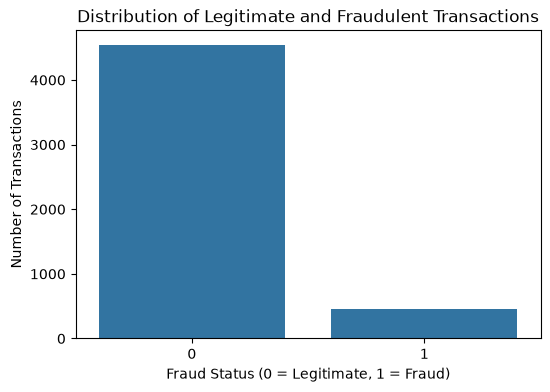

In [27]:
# Visualize the number of legitimate and fraudulent transactions
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="is_fraud")

# Add a descriptive title
plt.title("Distribution of Legitimate and Fraudulent Transactions")

# Label the x-axis
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")

# Label the y-axis
plt.ylabel("Number of Transactions")

plt.show()

11. Transaction Amount Analysis

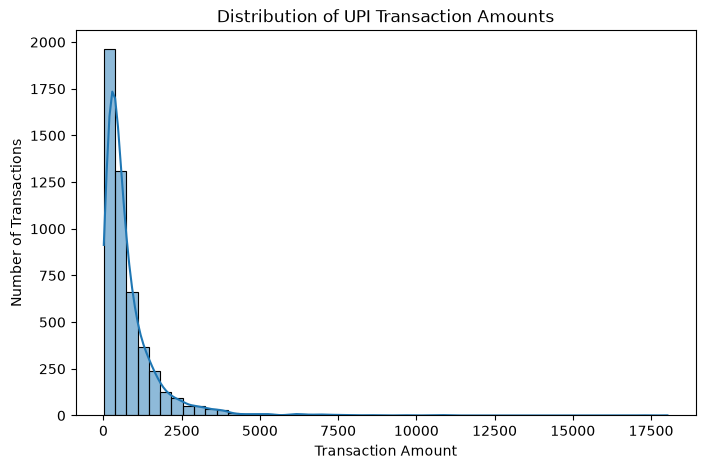

In [28]:
# Visualize the distribution of transaction amounts
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="amount", bins=50, kde=True)

plt.title("Distribution of UPI Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

12. Transaction Type Analysis

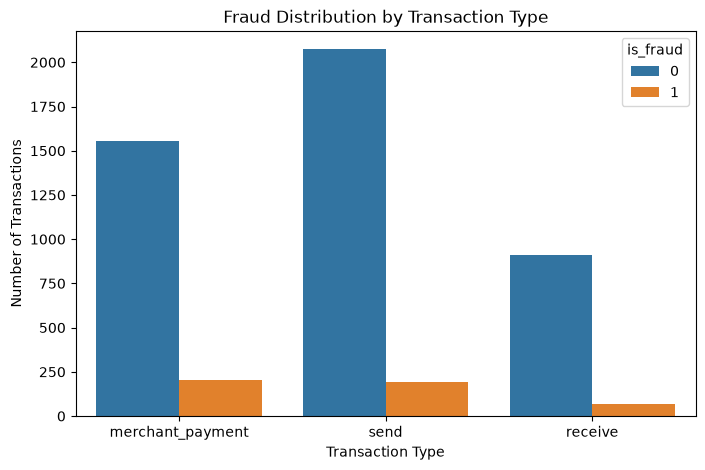

In [29]:
# Visualize transaction types according to fraud status
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="transaction_type",
    hue="is_fraud"
)

plt.title("Fraud Distribution by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.show()

13. Device Type Analysis

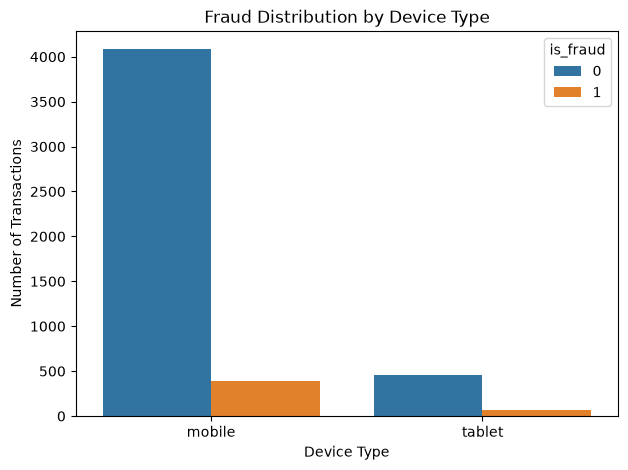

In [30]:
# Visualize legitimate and fraudulent transactions by device type
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="device_type",
    hue="is_fraud"
)

plt.title("Fraud Distribution by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Number of Transactions")

plt.show()

15. Network Type Analysis

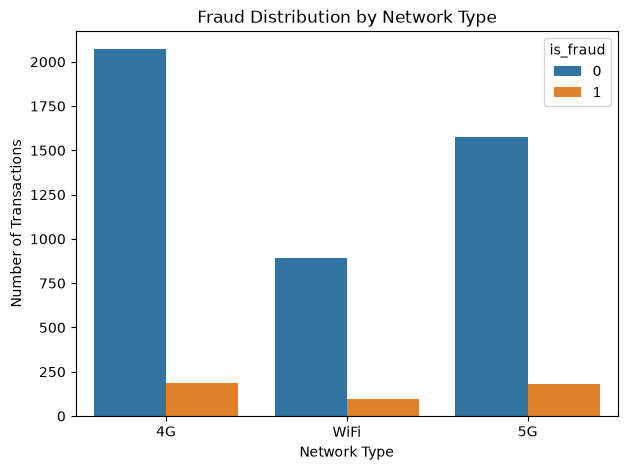

In [31]:
# Visualize fraud distribution across different network types
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="network_type",
    hue="is_fraud"
)

plt.title("Fraud Distribution by Network Type")
plt.xlabel("Network Type")
plt.ylabel("Number of Transactions")

plt.show()

17. Time-of-Day Analysis

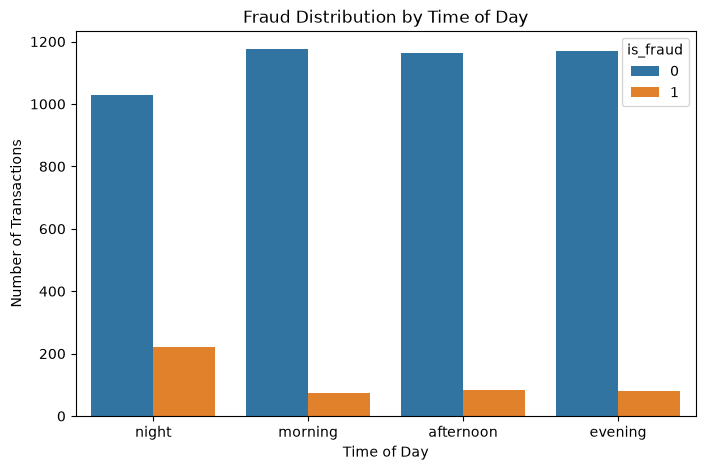

In [32]:
# Visualize transaction distribution by time of day and fraud status
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="time_of_day",
    hue="is_fraud"
)

plt.title("Fraud Distribution by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Transactions")

plt.show()

19. Correlation Analysis

In [33]:
# Select numerical columns because correlation requires numerical values
numeric_df = df.select_dtypes(include=np.number)

# Calculate the correlation between numerical features
correlation_matrix = numeric_df.corr()

# Display the correlation matrix
correlation_matrix

,transaction_id,user_id,receiver_id,amount,is_rooted_device,is_fraud,year,month,day,day_of_week,hour,is_weekend
transaction_id,1.000000e+00,0.017504,-0.016089,0.002130,-0.007748,-0.011917,NaN,0.996501,0.095346,-0.006959,0.002143,-3.070269e-17
user_id,1.750353e-02,1.000000,-0.023605,0.007894,0.016069,-0.016028,NaN,0.016240,0.014425,0.026976,-0.008504,2.093956e-02
receiver_id,-1.608924e-02,-0.023605,1.000000,0.014447,-0.005644,-0.001717,NaN,-0.014457,-0.019316,0.003148,-0.016298,1.481144e-02
amount,2.129621e-03,0.007894,0.014447,1.000000,0.030973,0.009293,NaN,0.000105,0.027084,0.001315,-0.020608,7.520463e-03
is_rooted_device,-7.747839e-03,0.016069,-0.005644,0.030973,1.000000,0.205335,NaN,-0.007709,-0.002188,0.008918,0.002190,-1.187133e-03
is_fraud,-1.191747e-02,-0.016028,-0.001717,0.009293,0.205335,1.000000,NaN,-0.010522,-0.011352,-0.027050,-0.120062,-1.910379e-02
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,9.965006e-01,0.016240,-0.014457,0.000105,-0.007709,-0.010522,NaN,1.000000,0.012111,-0.007817,-0.000582,3.755871e-04
day,9.534633e-02,0.014425,-0.019316,0.027084,-0.002188,-0.011352,NaN,0.012111,1.000000,0.010417,-0.000211,-3.546029e-03
day_of_week,-6.958868e-03,0.026976,0.003148,0.001315,0.008918,-0.027050,NaN,-0.007817,0.010417,1.000000,0.000210,7.910326e-01


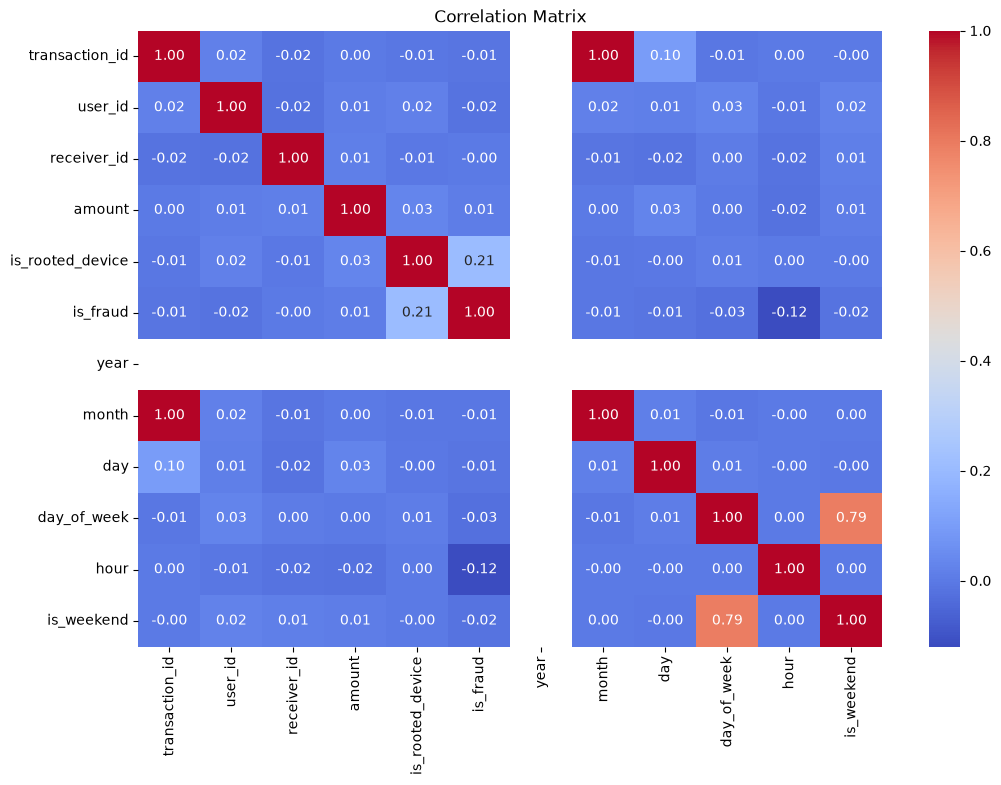

In [34]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

20. Final EDA Check

In [35]:
# Display the final number of rows and columns after feature engineering
df.shape

(5000, 18)

In [36]:
# Display all columns currently available in the dataset
df.columns.tolist()

['transaction_id',
 'timestamp',
 'user_id',
 'receiver_id',
 'amount',
 'transaction_type',
 'location',
 'device_type',
 'is_rooted_device',
 'network_type',
 'time_of_day',
 'is_fraud',
 'year',
 'month',
 'day',
 'day_of_week',
 'hour',
 'is_weekend']

In [37]:
# Display the first five records after completing EDA-related preparation
df.head()

,transaction_id,timestamp,user_id,receiver_id,amount,transaction_type,location,device_type,is_rooted_device,network_type,time_of_day,is_fraud,year,month,day,day_of_week,hour,is_weekend
0,100001,2025-01-01 00:00:00.000000,1103,5974,257.67,merchant_payment,Ahmedabad,mobile,0,4G,night,0,2025,1,1,2,0,0
1,100002,2025-01-01 01:45:08.461492,1436,5632,216.09,merchant_payment,Delhi,mobile,0,WiFi,night,0,2025,1,1,2,1,0
2,100003,2025-01-01 03:30:16.922984,1861,5894,190.54,send,Pune,mobile,0,5G,night,0,2025,1,1,2,3,0
3,100004,2025-01-01 05:15:25.384476,1271,5567,403.96,receive,Bangalore,mobile,1,4G,night,1,2025,1,1,2,5,0
4,100005,2025-01-01 07:00:33.845969,1107,5027,591.74,merchant_payment,Kolkata,mobile,0,WiFi,morning,1,2025,1,1,2,7,0


21. Prepare Data for Machine Learning

21.1 Check the current columns


In [38]:
# Display all columns before selecting features for machine learning
# This helps us decide which columns should be used as model inputs
df.columns.tolist()

['transaction_id',
 'timestamp',
 'user_id',
 'receiver_id',
 'amount',
 'transaction_type',
 'location',
 'device_type',
 'is_rooted_device',
 'network_type',
 'time_of_day',
 'is_fraud',
 'year',
 'month',
 'day',
 'day_of_week',
 'hour',
 'is_weekend']

21.2 Separate features and target
Our target is is_fraud.

In [39]:
# Separate the target variable from the input features
# X contains the information used by the model for prediction
# y contains the value the model needs to predict
X = df.drop(columns=["is_fraud"])

# Store the fraud indicator as the target variable
# 0 = Legitimate transaction
# 1 = Fraudulent transaction
y = df["is_fraud"]

# Check the shape of the input features
X.shape

(5000, 17)


22. Remove Columns That Shouldn't Be Used
We don't want identifiers to become meaningless predictive signals.
transaction_id

In [40]:
# Remove transaction_id because it is only a unique identifier
# It does not describe the behavior or characteristics of a transaction
X = X.drop(columns=["transaction_id"])

user_id and receiver_id
For this first version, we'll also exclude these IDs:

In [41]:
# Remove user and receiver identifiers
# These are identifiers rather than meaningful transaction characteristics
# Keeping them could make the model memorize individual IDs instead of learning general patterns
X = X.drop(columns=["user_id", "receiver_id"])

## Remove raw timestamp
We already extracted useful time features such as:

year

month

day

day_of_week

hour

is_weekend

Therefore:

In [42]:
# Remove the original timestamp after extracting useful time-based features
# Machine-learning models cannot directly work with raw datetime values
X = X.drop(columns=["timestamp"])

Check:

In [43]:
# Display the features that will be considered for machine learning
X.columns.tolist()

['amount',
 'transaction_type',
 'location',
 'device_type',
 'is_rooted_device',
 'network_type',
 'time_of_day',
 'year',
 'month',
 'day',
 'day_of_week',
 'hour',
 'is_weekend']

23. Train-Test Split
We shouldn't train the model using the entire dataset.

In [44]:
# Import train_test_split from Scikit-learn
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% of the data is used for training
# 20% is reserved for final evaluation
# stratify=y keeps approximately the same fraud/legitimate ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Check the sizes:

In [45]:
# Display the size of the training and testing datasets
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (4000, 13)
Testing features: (1000, 13)
Training target: (4000,)
Testing target: (1000,)


Why random_state=42?
# random_state ensures that the same random split is produced every time
# This makes our experiment reproducible

Why stratify=y?
# stratify=y preserves the proportion of legitimate and fraudulent transactions
# in both training and testing datasets

24. Identify Numerical and Categorical Features

In [46]:
# Identify numerical features that contain numeric values
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

# Identify categorical features that contain text/categories
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

# Display numerical features
print("Numerical Features:")
print(numerical_features.tolist())

# Display categorical features
print("\nCategorical Features:")
print(categorical_features.tolist())

Numerical Features:
['amount', 'is_rooted_device', 'is_weekend']

Categorical Features:
['transaction_type', 'location', 'device_type', 'network_type', 'time_of_day']


25. Preprocessing Pipeline
Instead of manually encoding and scaling everything, we'll use a Scikit-learn ColumnTransformer.

First import:

In [47]:
# StandardScaler standardizes numerical features
from sklearn.preprocessing import StandardScaler

# OneHotEncoder converts categorical values into numerical columns
from sklearn.preprocessing import OneHotEncoder

# ColumnTransformer allows different preprocessing for different column types
from sklearn.compose import ColumnTransformer

Create the preprocessing pipeline:

In [48]:
# Create preprocessing for numerical features
# StandardScaler transforms numerical values to a common scale
numerical_transformer = StandardScaler()

# Create preprocessing for categorical features
# OneHotEncoder converts categories into binary numerical columns
# handle_unknown="ignore" prevents errors if a new category appears during testing
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Apply the appropriate preprocessing to each group of columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

26. Fit Preprocessing Only on Training Data
This is an important improvement over the old project.

In [49]:
# Learn preprocessing parameters only from the training data
# This prevents information from the test set leaking into the training process
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the already-learned transformations to the test data
# We use transform() rather than fit_transform() for the test set
X_test_processed = preprocessor.transform(X_test)

Check:

In [50]:
# Display the shape of the processed training and testing data
print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (4000, 23)
Processed testing data: (1000, 23)


27. Baseline Model — Logistic Regression
Before using advanced models, we'll establish a baseline.

In [51]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Create the baseline Logistic Regression model
# class_weight="balanced" gives more importance to the minority fraud class
logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

Train it:

In [52]:
# Train the Logistic Regression model using the processed training data
logistic_model.fit(
    X_train_processed,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

Make predictions:

In [53]:
# Predict the fraud class for the test transactions
y_pred_logistic = logistic_model.predict(X_test_processed)

# Predict the probability of fraud for each test transaction
# [:, 1] selects the probability of class 1 (fraud)
y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

28. Evaluate the Baseline

In [54]:
# Import common classification evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [55]:
# Calculate baseline performance metrics
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)
logistic_roc_auc = roc_auc_score(y_test, y_prob_logistic)

# Display the evaluation results
print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)
print("ROC-AUC  :", logistic_roc_auc)

Logistic Regression Results
---------------------------
Accuracy : 0.703
Precision: 0.1806853582554517
Recall   : 0.6304347826086957
F1 Score : 0.28087167070217917
ROC-AUC  : 0.738041084083509


29. Decision Tree
Import the model

In [56]:
# Import Decision Tree Classifier from Scikit-learn
# A Decision Tree makes predictions by splitting data based on feature conditions
from sklearn.tree import DecisionTreeClassifier

In [57]:
# Create a Decision Tree classifier
# max_depth limits the tree depth and helps reduce overfitting
# class_weight="balanced" gives more importance to the minority fraud class
decision_tree_model = DecisionTreeClassifier(
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

In [58]:
# Train the Decision Tree using the preprocessed training data
decision_tree_model.fit(
    X_train_processed,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

In [59]:
# Predict the class of each test transaction
y_pred_dt = decision_tree_model.predict(
    X_test_processed
)

# Get the probability of fraud for each test transaction
# [:, 1] selects the probability of class 1 (fraud)
y_prob_dt = decision_tree_model.predict_proba(
    X_test_processed
)[:, 1]

In [60]:
# Calculate Decision Tree evaluation metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_prob_dt)

# Display the results
print("Decision Tree Results")
print("---------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_roc_auc)

Decision Tree Results
---------------------
Accuracy : 0.699
Precision: 0.17034700315457413
Recall   : 0.5869565217391305
F1 Score : 0.26405867970660146
ROC-AUC  : 0.6597275426163569


In [61]:
# Display precision, recall, F1-score, and support for both classes
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.94      0.71      0.81       908
           1       0.17      0.59      0.26        92

    accuracy                           0.70      1000
   macro avg       0.56      0.65      0.54      1000
weighted avg       0.87      0.70      0.76      1000



30 .Random Forest

In [62]:
# Import Random Forest Classifier
# Random Forest combines multiple decision trees to improve prediction stability
from sklearn.ensemble import RandomForestClassifier

In [63]:
# Create the Random Forest model
# n_estimators=200 means the model will build 200 decision trees
# class_weight="balanced" gives additional importance to the minority fraud class
# random_state=42 makes the results reproducible
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [64]:
# Train the Random Forest using the preprocessed training data
random_forest_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [65]:
# Predict the fraud class for the test transactions
y_pred_rf = random_forest_model.predict(X_test_processed)

# Calculate fraud probability for each test transaction
# [:, 1] selects the probability of class 1 (fraud)
y_prob_rf = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

In [66]:
# Display the detailed classification report
# This shows performance separately for legitimate and fraudulent transactions
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       908
           1       0.18      0.23      0.20        92

    accuracy                           0.84      1000
   macro avg       0.55      0.56      0.56      1000
weighted avg       0.85      0.84      0.84      1000



XGBoost

In [67]:
# Import XGBoost classifier
# XGBoost builds trees sequentially, where each new tree tries to correct
# errors made by the previous trees
from xgboost import XGBClassifier

In [68]:
# Create the XGBoost model
# n_estimators controls the number of boosting rounds
# max_depth controls the complexity of each tree
# learning_rate controls how strongly each tree contributes
# random_state makes the experiment reproducible
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

In [69]:
# Train the XGBoost model using the processed training data
xgb_model.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [70]:
# Predict the fraud class for the test transactions
y_pred_xgb = xgb_model.predict(X_test_processed)

# Calculate the probability that each transaction is fraudulent
# [:, 1] selects the probability for class 1 (fraud)
y_prob_xgb = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [71]:
# Display the detailed classification report
# This shows how well XGBoost performs separately for legitimate and fraudulent transactions
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       908
           1       0.45      0.05      0.10        92

    accuracy                           0.91      1000
   macro avg       0.68      0.52      0.52      1000
weighted avg       0.87      0.91      0.87      1000



30. Handle Class Imbalance with SMOTE

In [72]:
# Import SMOTE (Synthetic Minority Over-sampling Technique)
# SMOTE creates synthetic samples for the minority class
# Here, the minority class is fraudulent transactions (is_fraud = 1)
from imblearn.over_sampling import SMOTE

In [73]:
# Count legitimate and fraudulent transactions in the training dataset
# This shows the class imbalance before applying SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
is_fraud
0    3631
1     369
Name: count, dtype: int64


In [74]:
# Create the SMOTE object
# random_state ensures that the same synthetic samples are generated each time
smote = SMOTE(random_state=42)

# Apply SMOTE only to the training data
# The test data must NOT be oversampled because it should represent unseen real-world data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [75]:
# Count the classes after applying SMOTE
# SMOTE should make the number of legitimate and fraudulent training samples equal
print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
is_fraud
0    3631
1    3631
Name: count, dtype: int64


In [76]:
# Display the class distribution before and after SMOTE
print("Original training data:")
print(y_train.value_counts())

print("\nTraining data after SMOTE:")
print(y_train_smote.value_counts())

Original training data:
is_fraud
0    3631
1     369
Name: count, dtype: int64

Training data after SMOTE:
is_fraud
0    3631
1    3631
Name: count, dtype: int64


Train Logistic Regression with SMOTE

In [77]:
# Create a Logistic Regression model for the SMOTE-balanced training data
# We don't need class_weight="balanced" here because SMOTE has already balanced the classes
logistic_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [78]:
# Train Logistic Regression using the SMOTE-balanced training data
logistic_smote.fit(
    X_train_smote,
    y_train_smote
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [79]:
# Predict the fraud class for the untouched test dataset
y_pred_logistic_smote = logistic_smote.predict(
    X_test_processed
)

# Calculate fraud probabilities for the test transactions
# [:, 1] selects the probability of class 1 (fraud)
y_prob_logistic_smote = logistic_smote.predict_proba(
    X_test_processed
)[:, 1]

In [81]:
# Calculate evaluation metrics after applying SMOTE
smote_accuracy = accuracy_score(
    y_test,
    y_pred_logistic_smote
)

smote_precision = precision_score(
    y_test,
    y_pred_logistic_smote
)

smote_recall = recall_score(
    y_test,
    y_pred_logistic_smote
)

smote_f1 = f1_score(
    y_test,
    y_pred_logistic_smote
)

smote_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic_smote
)

# Display the results
print("Logistic Regression + SMOTE")
print("---------------------------")
print("Accuracy :", smote_accuracy)
print("Precision:", smote_precision)
print("Recall   :", smote_recall)
print("F1 Score :", smote_f1)
print("ROC-AUC  :", smote_roc_auc)

Logistic Regression + SMOTE
---------------------------
Accuracy : 0.704
Precision: 0.18125
Recall   : 0.6304347826086957
F1 Score : 0.2815533980582524
ROC-AUC  : 0.7314570963416971


In [82]:
# Display the detailed classification report
# This shows performance separately for legitimate and fraudulent transactions
print(
    classification_report(
        y_test,
        y_pred_logistic_smote
    )
)

              precision    recall  f1-score   support

           0       0.95      0.71      0.81       908
           1       0.18      0.63      0.28        92

    accuracy                           0.70      1000
   macro avg       0.57      0.67      0.55      1000
weighted avg       0.88      0.70      0.76      1000



Random Forest + SMOTE

In [83]:
# Create a Random Forest model using the SMOTE-balanced training data
# Random Forest combines multiple decision trees to learn non-linear patterns
random_forest_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train Random Forest on the SMOTE-balanced training dataset
random_forest_smote.fit(
    X_train_smote,
    y_train_smote
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [84]:
# Predict legitimate/fraud classes on the untouched test dataset
y_pred_rf_smote = random_forest_smote.predict(
    X_test_processed
)

# Calculate fraud probabilities for the test transactions
y_prob_rf_smote = random_forest_smote.predict_proba(
    X_test_processed
)[:, 1]

In [85]:
# Calculate Random Forest + SMOTE evaluation metrics
rf_smote_accuracy = accuracy_score(y_test, y_pred_rf_smote)
rf_smote_precision = precision_score(y_test, y_pred_rf_smote)
rf_smote_recall = recall_score(y_test, y_pred_rf_smote)
rf_smote_f1 = f1_score(y_test, y_pred_rf_smote)
rf_smote_roc_auc = roc_auc_score(y_test, y_prob_rf_smote)

# Display the results
print("Random Forest + SMOTE Results")
print("-----------------------------")
print("Accuracy :", rf_smote_accuracy)
print("Precision:", rf_smote_precision)
print("Recall   :", rf_smote_recall)
print("F1 Score :", rf_smote_f1)
print("ROC-AUC  :", rf_smote_roc_auc)

Random Forest + SMOTE Results
-----------------------------
Accuracy : 0.847
Precision: 0.1411764705882353
Recall   : 0.13043478260869565
F1 Score : 0.13559322033898305
ROC-AUC  : 0.6871648151695078


In [86]:
# Display detailed performance for legitimate and fraudulent transactions
print(
    classification_report(
        y_test,
        y_pred_rf_smote
    )
)

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       908
           1       0.14      0.13      0.14        92

    accuracy                           0.85      1000
   macro avg       0.53      0.53      0.53      1000
weighted avg       0.84      0.85      0.84      1000



XGBoost + SMOTE

In [88]:
# Create an XGBoost model using the SMOTE-balanced training data
# SMOTE has increased the representation of fraudulent transactions
xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

# Train XGBoost on the SMOTE-balanced training data
xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [89]:
# Predict the class of transactions in the untouched test dataset
y_pred_xgb_smote = xgb_smote.predict(
    X_test_processed
)

# Calculate the probability of fraud for each test transaction
y_prob_xgb_smote = xgb_smote.predict_proba(
    X_test_processed
)[:, 1]

In [90]:
# Calculate XGBoost + SMOTE performance metrics
xgb_smote_accuracy = accuracy_score(
    y_test,
    y_pred_xgb_smote
)

xgb_smote_precision = precision_score(
    y_test,
    y_pred_xgb_smote
)

xgb_smote_recall = recall_score(
    y_test,
    y_pred_xgb_smote
)

xgb_smote_f1 = f1_score(
    y_test,
    y_pred_xgb_smote
)

xgb_smote_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb_smote
)

# Display the results
print("XGBoost + SMOTE Results")
print("-----------------------")
print("Accuracy :", xgb_smote_accuracy)
print("Precision:", xgb_smote_precision)
print("Recall   :", xgb_smote_recall)
print("F1 Score :", xgb_smote_f1)
print("ROC-AUC  :", xgb_smote_roc_auc)

XGBoost + SMOTE Results
-----------------------
Accuracy : 0.87
Precision: 0.18333333333333332
Recall   : 0.11956521739130435
F1 Score : 0.14473684210526316
ROC-AUC  : 0.6749185979697375


In [91]:
# Display detailed performance for legitimate and fraudulent transactions
print(
    classification_report(
        y_test,
        y_pred_xgb_smote
    )
)

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       908
           1       0.18      0.12      0.14        92

    accuracy                           0.87      1000
   macro avg       0.55      0.53      0.54      1000
weighted avg       0.85      0.87      0.86      1000



XGBoost with class weighting

In [93]:
# Count legitimate transactions in the training data
negative_class = (y_train == 0).sum()

# Count fraudulent transactions in the training data
positive_class = (y_train == 1).sum()

# Calculate the ratio of legitimate transactions to fraudulent transactions
# This gives more importance to the minority fraud class
scale_pos_weight = negative_class / positive_class

print("Legitimate transactions:", negative_class)
print("Fraudulent transactions:", positive_class)
print("Scale Pos Weight:", scale_pos_weight)

Legitimate transactions: 3631
Fraudulent transactions: 369
Scale Pos Weight: 9.840108401084011


In [94]:
# Create XGBoost with higher importance assigned to fraudulent transactions
# scale_pos_weight helps XGBoost handle class imbalance without creating synthetic data
xgb_weighted = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

In [95]:
# Train XGBoost using the original training data
# We do not use SMOTE here because class imbalance is handled through weighting
xgb_weighted.fit(
    X_train_processed,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [96]:
# Predict the fraud class for the untouched test dataset
y_pred_xgb_weighted = xgb_weighted.predict(
    X_test_processed
)

# Calculate fraud probability for each test transaction
y_prob_xgb_weighted = xgb_weighted.predict_proba(
    X_test_processed
)[:, 1]

In [97]:
# Calculate performance metrics for weighted XGBoost
xgb_weighted_accuracy = accuracy_score(
    y_test,
    y_pred_xgb_weighted
)

xgb_weighted_precision = precision_score(
    y_test,
    y_pred_xgb_weighted
)

xgb_weighted_recall = recall_score(
    y_test,
    y_pred_xgb_weighted
)

xgb_weighted_f1 = f1_score(
    y_test,
    y_pred_xgb_weighted
)

xgb_weighted_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb_weighted
)

# Display the results
print("XGBoost + Class Weighting Results")
print("---------------------------------")
print("Accuracy :", xgb_weighted_accuracy)
print("Precision:", xgb_weighted_precision)
print("Recall   :", xgb_weighted_recall)
print("F1 Score :", xgb_weighted_f1)
print("ROC-AUC  :", xgb_weighted_roc_auc)

XGBoost + Class Weighting Results
---------------------------------
Accuracy : 0.755
Precision: 0.1825726141078838
Recall   : 0.4782608695652174
F1 Score : 0.26426426426426425
ROC-AUC  : 0.6756727638383452


In [98]:
# Display detailed performance for legitimate and fraudulent transactions
print(
    classification_report(
        y_test,
        y_pred_xgb_weighted
    )
)

              precision    recall  f1-score   support

           0       0.94      0.78      0.85       908
           1       0.18      0.48      0.26        92

    accuracy                           0.76      1000
   macro avg       0.56      0.63      0.56      1000
weighted avg       0.87      0.76      0.80      1000



Hyperparameter Tuning

In [99]:
# Import GridSearchCV for systematic hyperparameter tuning
# It tests different combinations of parameters using cross-validation
from sklearn.model_selection import GridSearchCV

 Tune Logistic Regression

In [100]:
# Define different Logistic Regression parameters to test
# C controls the strength of regularization
# Smaller C = stronger regularization
# Larger C = weaker regularization
logistic_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
} 

In [101]:
# Create the base Logistic Regression model
# class_weight="balanced" gives additional importance to the fraud class
logistic_tuning_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

# Create GridSearchCV
# scoring="f1" focuses on balancing precision and recall for fraud detection
# cv=5 means 5-fold cross-validation
logistic_grid = GridSearchCV(
    estimator=logistic_tuning_model,
    param_grid=logistic_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Train and test all parameter combinations using cross-validation
logistic_grid.fit(
    X_train_processed,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information pri

In [102]:
# Display the hyperparameters that produced the highest cross-validation F1-score
print("Best Logistic Regression Parameters:")
print(logistic_grid.best_params_)

# Display the best cross-validation F1-score
print("\nBest Cross-Validation F1 Score:")
print(logistic_grid.best_score_)

Best Logistic Regression Parameters:
{'C': 0.01, 'solver': 'lbfgs'}

Best Cross-Validation F1 Score:
0.28228667844337474


 Evaluate Tuned Logistic Regression

In [103]:
# Store the best Logistic Regression model found by GridSearchCV
best_logistic = logistic_grid.best_estimator_

# Predict fraud classes on the untouched test dataset
y_pred_logistic_tuned = best_logistic.predict(
    X_test_processed
)

# Calculate fraud probabilities
y_prob_logistic_tuned = best_logistic.predict_proba(
    X_test_processed
)[:, 1]

In [104]:
# Calculate evaluation metrics for the tuned Logistic Regression model
logistic_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_logistic_tuned
)

logistic_tuned_precision = precision_score(
    y_test,
    y_pred_logistic_tuned
)

logistic_tuned_recall = recall_score(
    y_test,
    y_pred_logistic_tuned
)

logistic_tuned_f1 = f1_score(
    y_test,
    y_pred_logistic_tuned
)

logistic_tuned_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic_tuned
)

print("Tuned Logistic Regression")
print("-------------------------")
print("Accuracy :", logistic_tuned_accuracy)
print("Precision:", logistic_tuned_precision)
print("Recall   :", logistic_tuned_recall)
print("F1 Score :", logistic_tuned_f1)
print("ROC-AUC  :", logistic_tuned_roc_auc)

Tuned Logistic Regression
-------------------------
Accuracy : 0.712
Precision: 0.1858974358974359
Recall   : 0.6304347826086957
F1 Score : 0.2871287128712871
ROC-AUC  : 0.7440744110323692


Tune XGBoost + Class Weighting

Now we'll tune the XGBoost model that performed best among our advanced models.

In [106]:
# Define XGBoost hyperparameters to test
# These parameters control tree complexity and learning behavior
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1]
}

In [107]:
# Create the base XGBoost model
# scale_pos_weight gives additional importance to fraudulent transactions
xgb_tuning_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Create GridSearchCV for XGBoost
# scoring="f1" focuses on the fraud-class F1-score
# cv=5 performs five-fold cross-validation
xgb_grid = GridSearchCV(
    estimator=xgb_tuning_model,
    param_grid=xgb_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

# Train all parameter combinations
xgb_grid.fit(
    X_train_processed,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.03, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0C

In [108]:
# Display the best XGBoost hyperparameters
print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

# Display the highest cross-validation F1-score
print("\nBest Cross-Validation F1 Score:")
print(xgb_grid.best_score_)

Best XGBoost Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Best Cross-Validation F1 Score:
0.28936602478627255


In [109]:
# Store the best XGBoost model found during tuning
best_xgb = xgb_grid.best_estimator_

# Predict fraud classes on the untouched test dataset
y_pred_xgb_tuned = best_xgb.predict(
    X_test_processed
)

# Calculate fraud probabilities
y_prob_xgb_tuned = best_xgb.predict_proba(
    X_test_processed
)[:, 1]

In [110]:
# Calculate evaluation metrics for tuned XGBoost
xgb_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_xgb_tuned
)

xgb_tuned_precision = precision_score(
    y_test,
    y_pred_xgb_tuned
)

xgb_tuned_recall = recall_score(
    y_test,
    y_pred_xgb_tuned
)

xgb_tuned_f1 = f1_score(
    y_test,
    y_pred_xgb_tuned
)

xgb_tuned_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb_tuned
)

print("Tuned XGBoost + Class Weighting")
print("--------------------------------")
print("Accuracy :", xgb_tuned_accuracy)
print("Precision:", xgb_tuned_precision)
print("Recall   :", xgb_tuned_recall)
print("F1 Score :", xgb_tuned_f1)
print("ROC-AUC  :", xgb_tuned_roc_auc)

Tuned XGBoost + Class Weighting
--------------------------------
Accuracy : 0.707
Precision: 0.18495297805642633
Recall   : 0.6413043478260869
F1 Score : 0.2871046228710462
ROC-AUC  : 0.7293262784907106


In [111]:
# Create a comparison table for the two tuned finalist models
finalist_comparison = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "Tuned XGBoost + Class Weighting"
    ],
    "Accuracy": [
        logistic_tuned_accuracy,
        xgb_tuned_accuracy
    ],
    "Precision": [
        logistic_tuned_precision,
        xgb_tuned_precision
    ],
    "Recall": [
        logistic_tuned_recall,
        xgb_tuned_recall
    ],
    "F1 Score": [
        logistic_tuned_f1,
        xgb_tuned_f1
    ],
    "ROC-AUC": [
        logistic_tuned_roc_auc,
        xgb_tuned_roc_auc
    ]
})

# Display the comparison
finalist_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Logistic Regression,0.712,0.185897,0.630435,0.287129,0.744074
1,Tuned XGBoost + Class Weighting,0.707,0.184953,0.641304,0.287105,0.729326


Threshold Optimization — Logistic Regression

In [112]:
# Create probability thresholds from 0.10 to 0.90
# Each threshold determines when a transaction is classified as fraud
thresholds = np.arange(0.10, 0.91, 0.05)

# Store Logistic Regression results for every threshold
logistic_threshold_results = []

# Test each probability threshold
for threshold in thresholds:

    # Convert predicted probabilities into binary predictions
    # Probability >= threshold → Fraud (1)
    # Probability < threshold → Legitimate (0)
    y_pred = (y_prob_logistic_tuned >= threshold).astype(int)

    # Calculate precision at the current threshold
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # Calculate recall at the current threshold
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # Calculate F1-score at the current threshold
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # Store the results
    logistic_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Convert results into a DataFrame
logistic_threshold_df = pd.DataFrame(
    logistic_threshold_results
)

# Display all threshold results
logistic_threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.10,0.092000,1.000000,0.168498
1,0.15,0.092000,1.000000,0.168498
2,0.20,0.092000,1.000000,0.168498
3,0.25,0.092369,1.000000,0.169118
4,0.30,0.096529,0.967391,0.175542
5,0.35,0.118457,0.934783,0.210269
6,0.40,0.136961,0.793478,0.233600
7,0.45,0.167901,0.739130,0.273642
8,0.50,0.185897,0.630435,0.287129
9,0.55,0.203846,0.576087,0.301136


In [113]:
# Find the threshold that produces the highest F1-score
best_logistic_threshold = logistic_threshold_df.loc[
    logistic_threshold_df["F1 Score"].idxmax()
]

# Display the best threshold and its metrics
best_logistic_threshold

Threshold    0.600000
Precision    0.242775
Recall       0.456522
F1 Score     0.316981
Name: 10, dtype: float64

Threshold Optimization — XGBoost

In [114]:
# Store XGBoost results for every probability threshold
xgb_threshold_results = []

# Test the same thresholds used for Logistic Regression
for threshold in thresholds:

    # Convert XGBoost fraud probabilities into binary predictions
    y_pred = (y_prob_xgb_tuned >= threshold).astype(int)

    # Calculate precision
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # Calculate recall
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # Calculate F1-score
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # Store the results
    xgb_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Convert the results into a DataFrame
xgb_threshold_df = pd.DataFrame(
    xgb_threshold_results
)

# Display the threshold results
xgb_threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.10,0.092742,1.000000,0.169742
1,0.15,0.093591,1.000000,0.171163
2,0.20,0.093783,0.967391,0.170989
3,0.25,0.104067,0.945652,0.187500
4,0.30,0.119942,0.902174,0.211735
5,0.35,0.133681,0.836957,0.230539
6,0.40,0.150905,0.815217,0.254669
7,0.45,0.163317,0.706522,0.265306
8,0.50,0.184953,0.641304,0.287105
9,0.55,0.192171,0.586957,0.289544


In [115]:
# Find the threshold that produces the highest F1-score
best_xgb_threshold = xgb_threshold_df.loc[
    xgb_threshold_df["F1 Score"].idxmax()
]

# Display the best threshold and its metrics
best_xgb_threshold

Threshold    0.750000
Precision    0.476190
Recall       0.217391
F1 Score     0.298507
Name: 13, dtype: float64

In [116]:
# Create a comparison table using the best threshold for each model
optimized_comparison = pd.DataFrame({
    "Model": [
        "Tuned Logistic Regression",
        "Tuned XGBoost + Class Weighting"
    ],
    "Best Threshold": [
        best_logistic_threshold["Threshold"],
        best_xgb_threshold["Threshold"]
    ],
    "Precision": [
        best_logistic_threshold["Precision"],
        best_xgb_threshold["Precision"]
    ],
    "Recall": [
        best_logistic_threshold["Recall"],
        best_xgb_threshold["Recall"]
    ],
    "F1 Score": [
        best_logistic_threshold["F1 Score"],
        best_xgb_threshold["F1 Score"]
    ]
})

# Display the optimized model comparison
optimized_comparison

,Model,Best Threshold,Precision,Recall,F1 Score
0,Tuned Logistic Regression,0.60,0.242775,0.456522,0.316981
1,Tuned XGBoost + Class Weighting,0.75,0.476190,0.217391,0.298507


In [119]:
# Set the optimized probability threshold for the final Logistic Regression model
# A transaction is classified as fraud when its predicted probability is >= 0.60
final_threshold = 0.60

# Convert fraud probabilities into final binary predictions
# 1 = Fraud
# 0 = Legitimate
y_pred_final = (
    y_prob_logistic_tuned >= final_threshold
).astype(int)

# Display the first few final predictions
y_pred_final[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1])

In [120]:
# Calculate the final performance metrics using the optimized threshold
final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

# ROC-AUC is calculated using probabilities rather than the thresholded predictions
final_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic_tuned
)

# Display the final model performance
print("FINAL MODEL PERFORMANCE")
print("-----------------------")
print("Model     : Tuned Logistic Regression")
print("Threshold :", final_threshold)
print("Accuracy  :", final_accuracy)
print("Precision :", final_precision)
print("Recall    :", final_recall)
print("F1 Score  :", final_f1)
print("ROC-AUC   :", final_roc_auc)

FINAL MODEL PERFORMANCE
-----------------------
Model     : Tuned Logistic Regression
Threshold : 0.6
Accuracy  : 0.819
Precision : 0.24277456647398843
Recall    : 0.45652173913043476
F1 Score  : 0.3169811320754717
ROC-AUC   : 0.7440744110323692


Confusion Matrix

In [121]:
# Import confusion_matrix to calculate TP, TN, FP, and FN
from sklearn.metrics import confusion_matrix

In [122]:
# Calculate the confusion matrix using the final predictions
# Rows represent the actual class
# Columns represent the predicted class
conf_matrix = confusion_matrix(
    y_test,
    y_pred_final
)

# Display the confusion matrix values
conf_matrix

array([[777, 131],
       [ 50,  42]])

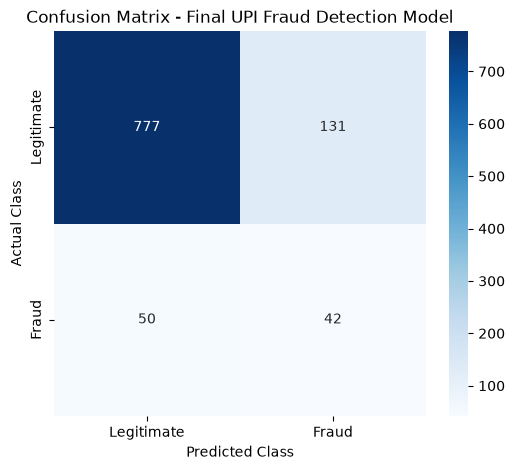

In [123]:
# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

# Add descriptive labels
plt.title("Confusion Matrix - Final UPI Fraud Detection Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [124]:
# Display precision, recall, F1-score, and support for the final model
print(
    classification_report(
        y_test,
        y_pred_final
    )
)

              precision    recall  f1-score   support

           0       0.94      0.86      0.90       908
           1       0.24      0.46      0.32        92

    accuracy                           0.82      1000
   macro avg       0.59      0.66      0.61      1000
weighted avg       0.88      0.82      0.84      1000



In [125]:
# Extract TN, FP, FN, and TP from the confusion matrix
tn, fp, fn, tp = conf_matrix.ravel()

# Display each value with its meaning
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

True Negatives (TN): 777
False Positives (FP): 131
False Negatives (FN): 50
True Positives (TP): 42


ROC Curve - we should evaluate the final model visually and then inspect which features influenced its predictions.

In [126]:
# Import the ROC curve function
# ROC curve shows the model's ability to separate legitimate and fraudulent transactions
from sklearn.metrics import roc_curve, auc

In [127]:
# Calculate False Positive Rate and True Positive Rate at different probability thresholds
fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_prob_logistic_tuned
)

# Calculate the Area Under the ROC Curve
roc_auc = auc(fpr, tpr)

# Display ROC-AUC
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7440744110323692


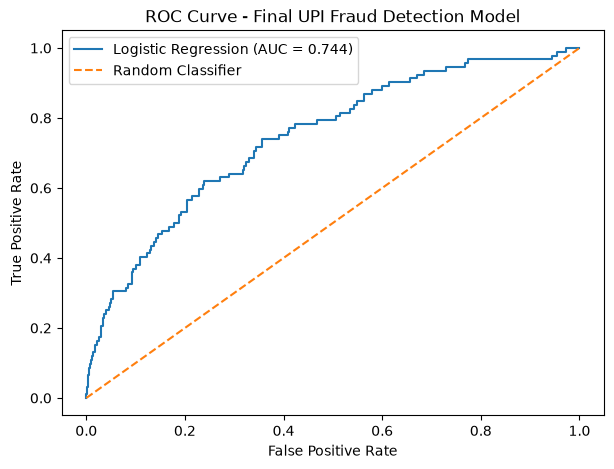

In [128]:
# Plot the ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

# Plot the random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Final UPI Fraud Detection Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

Why ROC-AUC?
ROC-AUC evaluates the model's ability to rank fraudulent transactions above legitimate ones across different thresholds. It doesn't depend only on our selected 0.60 threshold.

Precision-Recall Curve - For a fraud-detection problem, this is especially useful because our dataset is imbalanced.

In [129]:
# Import the Precision-Recall curve function
from sklearn.metrics import precision_recall_curve

In [130]:
# Calculate precision and recall at different probability thresholds
precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob_logistic_tuned
)

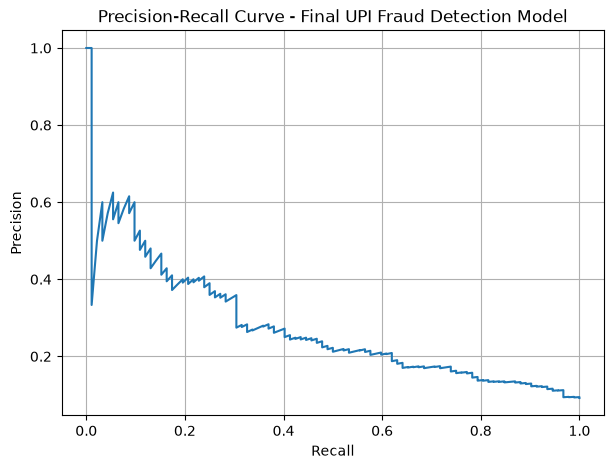

In [131]:
# Plot the Precision-Recall curve
plt.figure(figsize=(7, 5))

plt.plot(
    recall_values,
    precision_values
)

plt.title("Precision-Recall Curve - Final UPI Fraud Detection Model")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.grid(True)
plt.show()

Why this curve matters
It shows the trade-off:
Higher Recall
     ↓
Catch more fraud
     ↓
Usually more false alerts
     ↓
Lower Precision

Feature Importance — Logistic Regression - Because our final model is Logistic Regression, we can inspect its coefficients.

In [132]:
# Get the feature names after one-hot encoding
# This shows the actual features used internally by Logistic Regression
feature_names = preprocessor.get_feature_names_out()

# Get the coefficients learned by the Logistic Regression model
coefficients = best_logistic.coef_[0]

# Create a DataFrame containing features and their coefficients
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Calculate the absolute coefficient value
# Larger absolute values indicate stronger influence on the prediction
feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

# Sort features from strongest to weakest influence
feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

# Display the top 15 influential features
feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
22,cat__time_of_day_night,0.685885,0.685885
1,num__is_rooted_device,0.374120,0.374120
21,cat__time_of_day_morning,-0.270217,0.270217
3,cat__transaction_type_merchant_payment,0.235450,0.235450
14,cat__device_type_mobile,-0.227932,0.227932
15,cat__device_type_tablet,0.224732,0.224732
20,cat__time_of_day_evening,-0.223707,0.223707
19,cat__time_of_day_afternoon,-0.195161,0.195161
7,cat__location_Bangalore,-0.184003,0.184003
4,cat__transaction_type_receive,-0.172632,0.172632


Visualize top features

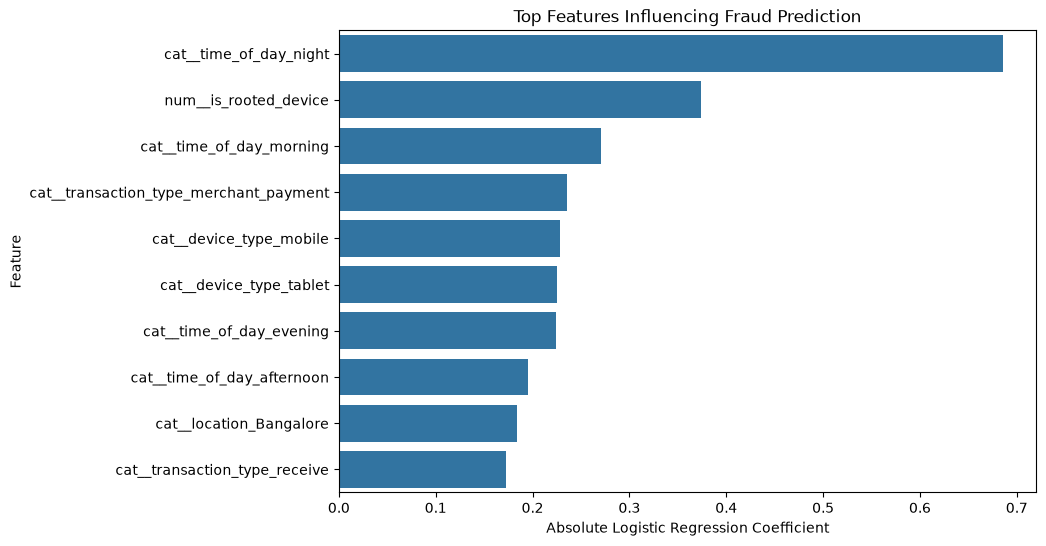

In [133]:
# Select the 10 most influential features
top_features = feature_importance.head(10)

# Create a horizontal bar chart
plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_features,
    x="Absolute_Coefficient",
    y="Feature"
)

plt.title("Top Features Influencing Fraud Prediction")
plt.xlabel("Absolute Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.show()

Save the Final Model

In [134]:
# Import joblib for saving Python machine-learning objects
import joblib

In [135]:
# Create a dictionary containing everything required for prediction
# The preprocessing pipeline is required to transform new transactions
# The model performs the final fraud prediction
# The threshold is required because we selected 0.60 instead of the default 0.50
final_model_artifact = {
    "model": best_logistic,
    "preprocessor": preprocessor,
    "threshold": final_threshold
}

# Save the complete model artifact
joblib.dump(
    final_model_artifact,
    "../models/upi_fraud_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.
